In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
Load Datasheet

In [4]:
df = pd.read_csv("model_ready_parts.csv")
print(df.head())
print(df.info())

        part_id                     part_name year_month  year  month  \
0  06179KZAW00S  CABLE SET THROT-06179KZAW00S    2023-12  2023     12   
1  06179KZAW00S  CABLE SET THROT-06179KZAW00S    2024-01  2024      1   
2  06179KZAW00S  CABLE SET THROT-06179KZAW00S    2024-02  2024      2   
3  06179KZAW00S  CABLE SET THROT-06179KZAW00S    2024-03  2024      3   
4  06179KZAW00S  CABLE SET THROT-06179KZAW00S    2024-04  2024      4   

  product_category product_type  hsn_number  target_demand_qty  purchase_qty  \
0       HHML Parts  Spare Parts  87141090.0                0.0           0.0   
1       HHML Parts  Spare Parts  87141090.0                0.0           0.0   
2       HHML Parts  Spare Parts  87141090.0                0.0           0.0   
3       HHML Parts  Spare Parts  87141090.0                0.0           0.0   
4       HHML Parts  Spare Parts  87141090.0                0.0           0.0   

   ...  demand_lag_12m  demand_rolling_3m_avg  demand_rolling_6m_avg  \
0  ...  

In [5]:
print(df.isnull().sum())

part_id                           0
part_name                      5075
year_month                        0
year                              0
month                             0
product_category               5075
product_type                  20387
hsn_number                    20387
target_demand_qty                 0
purchase_qty                      0
purchase_invoice_value            0
n_purchase_invoices               0
n_suppliers                       0
veh_sales_qty                     0
veh_sales_bill_amount             0
sales_qty                         0
service_qty                       0
sales_total_invoice_amount        0
n_sales_invoices                  0
n_sales_customers                 0
service_retail_amount             0
n_service_invoices                0
demand_lag_1m                  5420
demand_lag_2m                 10840
demand_lag_3m                 16260
demand_lag_6m                 32520
demand_lag_12m                65040
demand_rolling_3m_avg       

In [7]:
print(df.columns)

Index(['part_id', 'part_name', 'year_month', 'year', 'month',
       'product_category', 'product_type', 'hsn_number', 'target_demand_qty',
       'purchase_qty', 'purchase_invoice_value', 'n_purchase_invoices',
       'n_suppliers', 'veh_sales_qty', 'veh_sales_bill_amount', 'sales_qty',
       'service_qty', 'sales_total_invoice_amount', 'n_sales_invoices',
       'n_sales_customers', 'service_retail_amount', 'n_service_invoices',
       'demand_lag_1m', 'demand_lag_2m', 'demand_lag_3m', 'demand_lag_6m',
       'demand_lag_12m', 'demand_rolling_3m_avg', 'demand_rolling_6m_avg',
       'demand_std_3m', 'sales_revenue_lag_1m', 'n_sales_invoices_lag_1m',
       'service_qty_lag_1m', 'service_revenue_lag_1m', 'purchase_qty_lag_1m',
       'months_since_last_demand'],
      dtype='object')


In [8]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [9]:
df.dropna(inplace=True)

In [10]:
print(df.isnull().sum())

part_id                       0
part_name                     0
year_month                    0
year                          0
month                         0
product_category              0
product_type                  0
hsn_number                    0
target_demand_qty             0
purchase_qty                  0
purchase_invoice_value        0
n_purchase_invoices           0
n_suppliers                   0
veh_sales_qty                 0
veh_sales_bill_amount         0
sales_qty                     0
service_qty                   0
sales_total_invoice_amount    0
n_sales_invoices              0
n_sales_customers             0
service_retail_amount         0
n_service_invoices            0
demand_lag_1m                 0
demand_lag_2m                 0
demand_lag_3m                 0
demand_lag_6m                 0
demand_lag_12m                0
demand_rolling_3m_avg         0
demand_rolling_6m_avg         0
demand_std_3m                 0
sales_revenue_lag_1m          0
n_sales_

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df['year_month']=pd.to_datetime(df['year_month'],errors='coerce')

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
cat_cols=df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col]=le.fit_transform(df[col])

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
num_cols=df.select_dtypes(include=['int64','float64']).columns
df[num_cols]=scaler.fit_transform(df[num_cols])

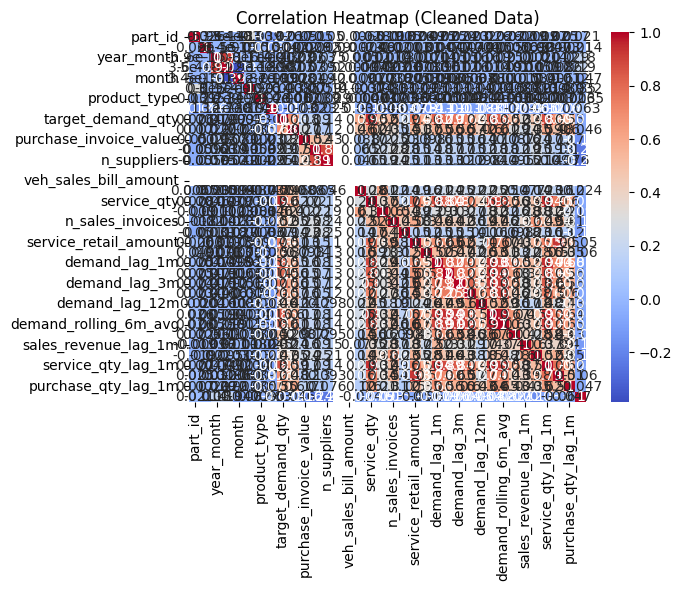

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap (Cleaned Data)")
plt.show()

In [17]:
df.to_csv("cleaned_model_ready.csv",index=False)